# Operaciones básicas con imágenes

En este cuaderno vas a trabajar con un conjunto pequeño de operaciones elementales sobre imágenes. El foco está en entender cómo se manipula una imagen como arreglo y cómo cambian sus dimensiones o su orientación.


## Objetivo

Leer una imagen como una estructura de filas, columnas y canales, y aplicar algunas operaciones iniciales sin mezclar todavía demasiadas técnicas distintas.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- interpretar la forma de una imagen como alto, ancho y canales;
- recortar una región usando coordenadas de filas y columnas;
- redimensionar una imagen;
- generar un volteo y una rotación simple;
- describir qué cambia en cada caso.

## Relación con la secuencia

Este cuaderno funciona como base operativa. La idea es fijar pocas transformaciones con claridad, antes de pasar a notebooks más específicos sobre perspectiva, anotación, segmentación o contornos.


## Módulos que vamos a usar

- `cv2`: para leer, redimensionar, rotar y voltear imágenes.
- `matplotlib.pyplot`: para mostrar comparaciones.
- `pathlib.Path`: para ubicar el archivo con el que vamos a trabajar.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt

ruta_imagen = Path("Imagenes") / "small-boats_1.jpg"
imagen_bgr = cv2.imread(str(ruta_imagen), cv2.IMREAD_COLOR)
if imagen_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_imagen}")

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
alto, ancho, canales = imagen_rgb.shape

print(f"Alto: {alto}")
print(f"Ancho: {ancho}")
print(f"Canales: {canales}")


Alto: 795
Ancho: 1200
Canales: 3


## 1. Ver la imagen original

Antes de modificar nada, conviene mirar la imagen completa y registrar sus dimensiones. Eso ayuda a interpretar mejor cualquier recorte o transformación posterior.


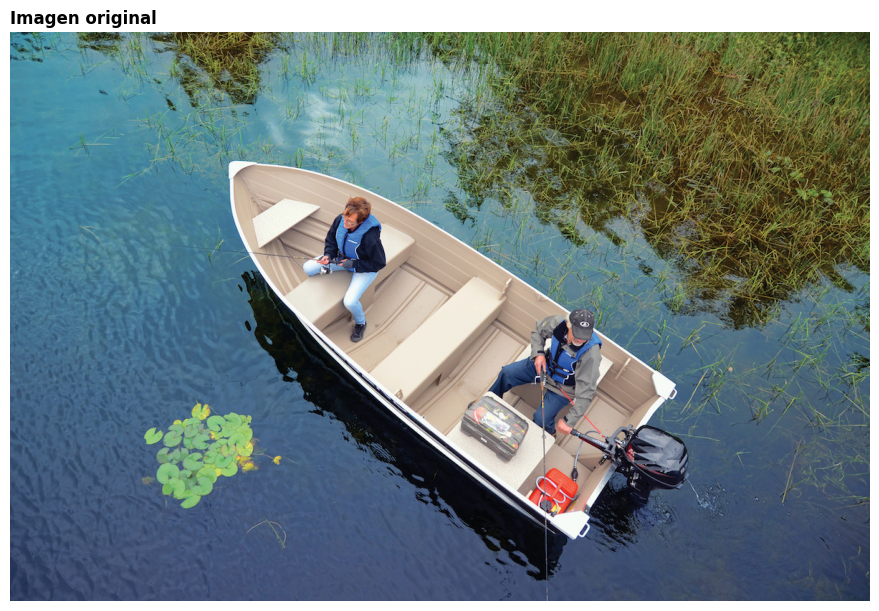

In [2]:
plt.figure(figsize=(9, 6), constrained_layout=True)
plt.imshow(imagen_rgb)
plt.title("Imagen original", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


## 2. Recortar una región

Un recorte selecciona una parte de la imagen. En NumPy, el primer rango corresponde a filas y el segundo a columnas. Es decir: primero `y` y después `x`.


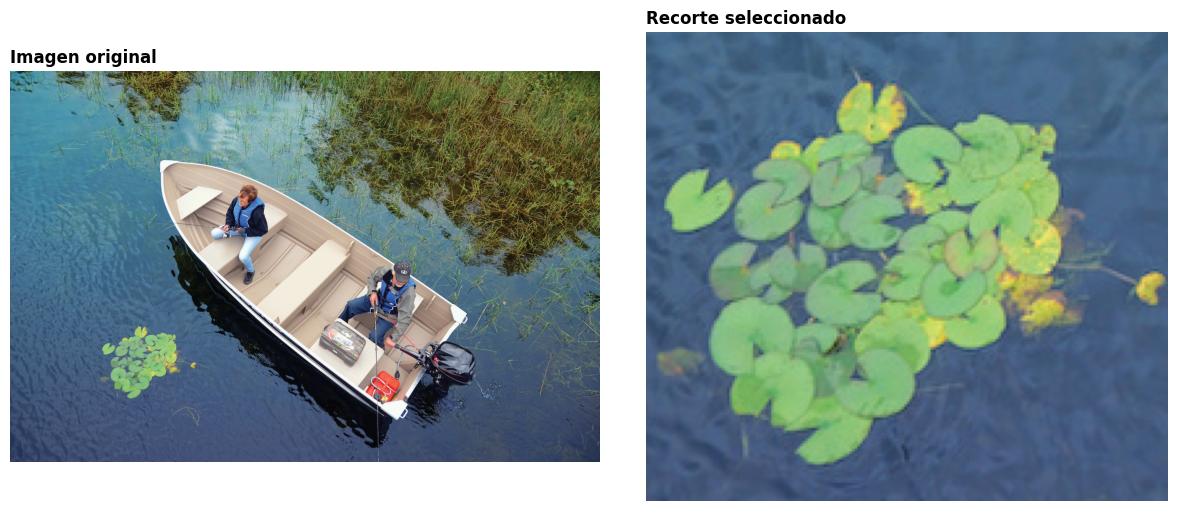

In [3]:
fila_inicial = 500
fila_final = 680
columna_inicial = 180
columna_final = 380

imagen_recortada = imagen_rgb[fila_inicial:fila_final, columna_inicial:columna_final]

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ejes[0].imshow(imagen_rgb)
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_recortada)
ejes[1].set_title("Recorte seleccionado", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()


Fijate que el recorte no inventa información nueva. Solo toma una subregión de la imagen original. Por eso conviene elegir coordenadas con un propósito claro.


## 3. Redimensionar

Redimensionar cambia el tamaño de la imagen. En algunos casos sirve para preparar una entrada para un modelo; en otros, para hacer una visualización más cómoda.


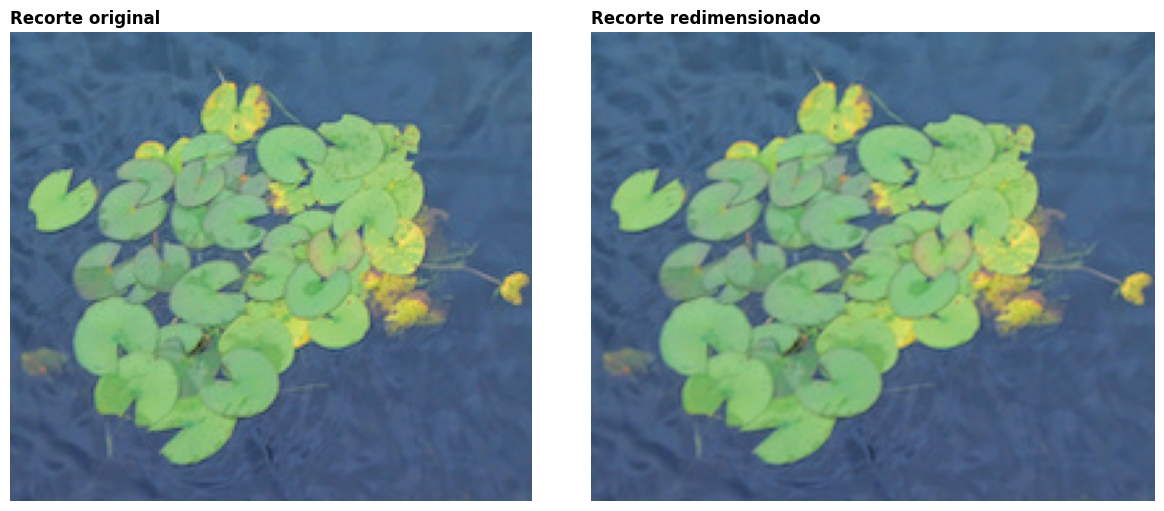

In [4]:
imagen_redimensionada = cv2.resize(imagen_recortada, (600, 500))

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ejes[0].imshow(imagen_recortada)
ejes[0].set_title("Recorte original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_redimensionada)
ejes[1].set_title("Recorte redimensionado", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()


## 4. Voltear la imagen

OpenCV permite generar reflejos horizontales o verticales. Esta operación es simple, pero ayuda a distinguir entre contenido visual y orientación espacial.


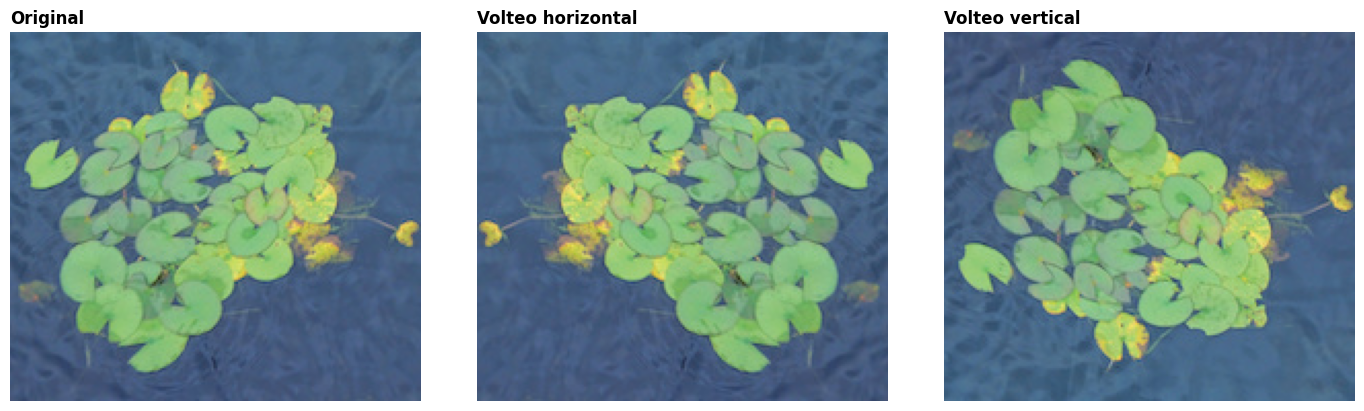

In [5]:
imagen_volteada_horizontal = cv2.flip(imagen_recortada, 1)
imagen_volteada_vertical = cv2.flip(imagen_recortada, 0)

fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
ejes[0].imshow(imagen_recortada)
ejes[0].set_title("Original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_volteada_horizontal)
ejes[1].set_title("Volteo horizontal", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_volteada_vertical)
ejes[2].set_title("Volteo vertical", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()


## 5. Rotar la imagen

Rotar implica reorganizar la orientación. Para una primera práctica, conviene usar una rotación controlada y mirar el resultado sin sumar todavía transformaciones más complejas.


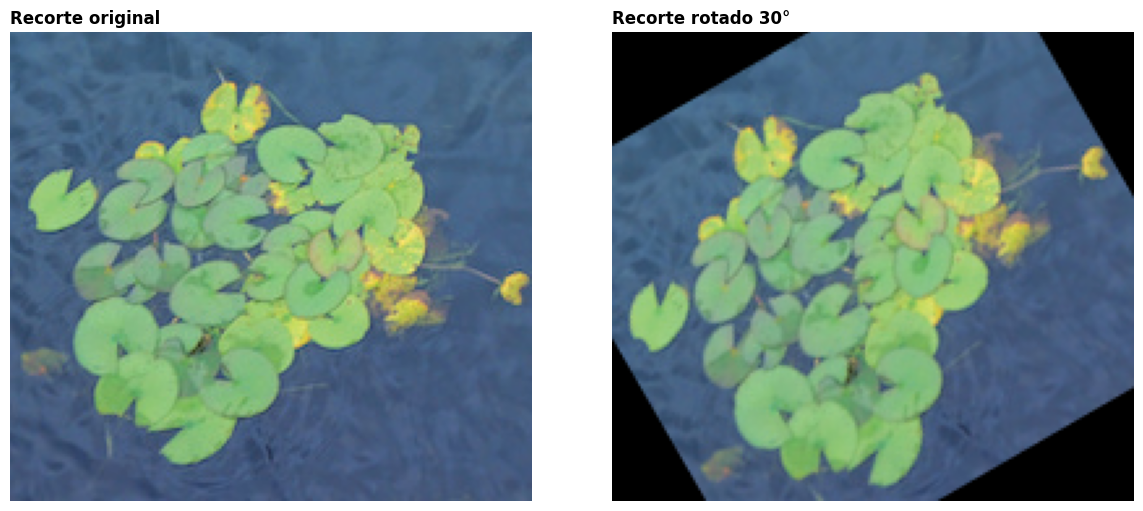

In [6]:
centro = (imagen_recortada.shape[1] // 2, imagen_recortada.shape[0] // 2)
matriz_rotacion = cv2.getRotationMatrix2D(centro, 30, 1.0)
imagen_rotada = cv2.warpAffine(
    imagen_recortada,
    matriz_rotacion,
    (imagen_recortada.shape[1], imagen_recortada.shape[0]),
)

fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ejes[0].imshow(imagen_recortada)
ejes[0].set_title("Recorte original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_rotada)
ejes[1].set_title("Recorte rotado 30°", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()


## Limitaciones y próximos pasos

Este cuaderno se concentra solo en unas pocas operaciones para no mezclar demasiadas ideas. Más adelante vas a trabajar transformaciones específicas con preguntas más claras: perspectiva, anotación, mejora de imagen, segmentación y detección.


## Actividad breve

Elegí otro recorte de la misma imagen y repetí estas operaciones. Después describí:

1. qué coordenadas usaste;
2. qué cambió al redimensionar;
3. qué diferencia conceptual hay entre voltear y rotar.


## Cierre

Leer una imagen como una matriz es el paso inicial para todo lo que viene después. Recortar, redimensionar, voltear o rotar parecen operaciones simples, pero fijan una idea clave: la imagen puede transformarse de manera controlada y cada transformación cambia algo distinto de su estructura.
